# Práctica 3: IA en salud

## Clasificación de Retinopatía Diabética

Contenido:
- Clasificación binaria (RD sí/no)
- Clasificación multiclase (grados 0-4)
- Red preentrenada (EfficientNet-B3)
- Data augmentation clínicamente motivado
- Smoke test sobre subconjunto pequeño
- Entrenamiento completo con AMP, scheduler y early stopping

Instalación de paquetes necesarios:

In [1]:
!pip install torch torchvision grad-cam opencv-python \
             albumentations matplotlib seaborn scikit-learn tqdm pandas \
             ipywidgets

Importación de paquetes necesarios:

In [2]:
import random, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models

from PIL import Image as PILImage
from IPython.display import display

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.preprocessing import label_binarize

from sklearn.model_selection import train_test_split

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, cohen_kappa_score,
                             RocCurveDisplay)

warnings.filterwarnings("ignore")

### 1. Configuración y semillas a utilizar

In [3]:
class Config:
    # ── Rutas ──────────────────────────────────────────
    TRAIN_DIR      = Path("4864-train")
    TEST_DIR       = Path("1216-test")
    OUTPUT_DIR     = Path("outputs")
    CHECKPOINT_DIR = Path("checkpoints")

    # ── Modo ───────────────────────────────────────────
    TASK       = "multiclass"  # "binary" | "multiclass"
    SMOKE_TEST = True          # ⚠️ cambiar a False para entrenar en serio

    # ── Dataset ────────────────────────────────────────
    NUM_CLASSES  = 5
    IMG_SIZE     = 224
    USE_CLAHE    = True
    VAL_SPLIT    = 0.2         # 20% de train → validación

    # ── Modelo ─────────────────────────────────────────
    MODEL_NAME      = "efficientnet_b3"
    PRETRAINED      = True
    FREEZE_BACKBONE = False

    # ── Entrenamiento ──────────────────────────────────
    EPOCHS               = 30
    BATCH_SIZE           = 4
    NUM_WORKERS          = 0
    LR                   = 1e-4
    WEIGHT_DECAY         = 1e-4
    LABEL_SMOOTHING      = 0.1
    USE_WEIGHTED_SAMPLER = True
    MIXED_PRECISION      = True

    # ── Early stopping ─────────────────────────────────
    PATIENCE  = 7

    # ── Scheduler ──────────────────────────────────────
    SCHEDULER     = "cosine"
    WARMUP_EPOCHS = 3

    # ── Smoke test ─────────────────────────────────────
    SMOKE_TRAIN_SIZE = 80
    SMOKE_VAL_SIZE   = 20
    SMOKE_EPOCHS     = 3

    # ── Reproducibilidad ───────────────────────────────
    SEED   = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

if cfg.TASK == "binary":
    cfg.NUM_CLASSES = 2

print(f"Tarea   : {cfg.TASK}")
print(f"Clases  : {cfg.NUM_CLASSES}")
print(f"Device  : {cfg.DEVICE}")
print(f"Smoke   : {cfg.SMOKE_TEST}")

Tarea   : multiclass
Clases  : 5
Device  : cpu
Smoke   : True


Configuración de las semillas y creación de las carpetas a utilizar:

In [4]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.SEED)

cfg.OUTPUT_DIR.mkdir(exist_ok=True)
cfg.CHECKPOINT_DIR.mkdir(exist_ok=True)
print("Semillas fijadas y carpetas creadas")

Semillas fijadas y carpetas creadas


Especificación de las etiquetas:

In [5]:
GRADES = {0: "Sin RD", 1: "Leve", 2: "Moderada", 3: "Severa", 4: "Proliferativa"}

BINARY_LABELS = {0: "Sin RD", 1: "Con RD"}

LABEL_NAMES = BINARY_LABELS if cfg.TASK == "binary" else GRADES
print("Clases activas:", LABEL_NAMES)

Clases activas: {0: 'Sin RD', 1: 'Leve', 2: 'Moderada', 3: 'Severa', 4: 'Proliferativa'}


### 2. Dataset, CLAHE y transforms

In [6]:
def apply_clahe(img: np.ndarray) -> np.ndarray:
    """
    CLAHE (Contrast Limited Adaptive Histogram Equalization)
    aplicado en el canal L del espacio LAB.

    ¿Por qué LAB y no directamente RGB?
    - L = luminosidad, A y B = color
    - Aplicar CLAHE solo en L mejora el contraste sin distorsionar los colores
    - Estándar en preprocesamiento de retinografías: mejora la visibilidad
      de microaneurismas, exudados y vasos sanguíneos finos
    """
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

Resize con aspect ratio correcto:

In [7]:
def resize_with_padding(img: np.ndarray, size: int) -> np.ndarray:
    """
    Resize manteniendo aspect ratio:
    1. Escala por el lado alto → el ancho queda mayor que size
    2. Crop central en horizontal → resultado cuadrado sin distorsión
    Para imágenes 4752x3168 (ratio 1.5):
        → resize a 768x512 → crop central → 512x512
    """
    h, w = img.shape[:2]
    scale = size / h
    new_h = size
    new_w = int(w * scale)
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    x = (new_w - size) // 2
    return img[:, x:x + size]

Visualización del efecto CLAHE:

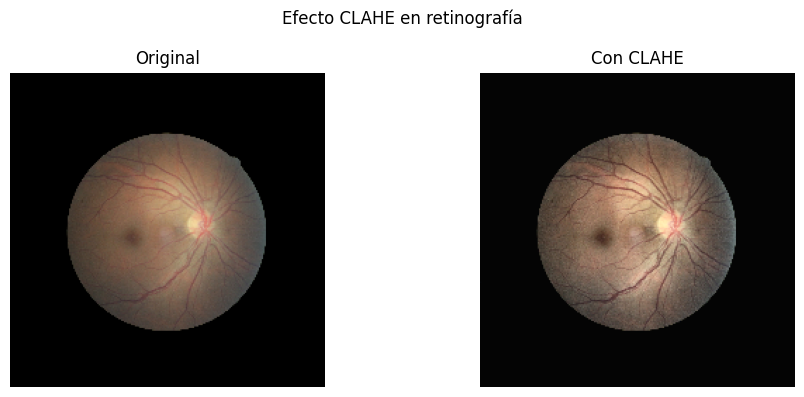

In [14]:
# Celda 9 — Visualizar efecto CLAHE
def plot_clahe_effect(img_path: str):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    scale = cfg.IMG_SIZE / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    img = cv2.resize(img, (new_w, new_h))

    pad_top    = (cfg.IMG_SIZE - new_h) // 2
    pad_bottom =  cfg.IMG_SIZE - new_h - pad_top
    pad_left   = (cfg.IMG_SIZE - new_w) // 2
    pad_right  =  cfg.IMG_SIZE - new_w - pad_left
    img = cv2.copyMakeBorder(img, pad_top, pad_bottom, pad_left, pad_right,
                             cv2.BORDER_CONSTANT, value=0)
    img_clahe = apply_clahe(img)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img);       axes[0].set_title("Original");  axes[0].axis("off")
    axes[1].imshow(img_clahe); axes[1].set_title("Con CLAHE"); axes[1].axis("off")
    plt.suptitle("Efecto CLAHE en retinografía")
    plt.tight_layout()
    plt.show()

img_path = next(Path(cfg.TRAIN_DIR / "0-noDR").glob("*.jpeg"))
plot_clahe_effect(str(img_path))

Realizamos data augmentation mediante las siguientes transformaciones:

In [15]:
def get_transforms(split: str):
    """
    Augmentations distintos según el split:
      - train   : augmentations clínicamente motivados
      - val/test : solo resize + normalización
 
    ¿Por qué estas augmentations para retinografía?
      - HorizontalFlip / VerticalFlip / RandomRotate90:
            la cámara puede capturar el ojo en distintas orientaciones
      - ShiftScaleRotate:
            variabilidad en el posicionamiento del paciente
      - RandomBrightnessContrast / HueSaturationValue:
            diferencias entre equipos (Topcon, Zeiss, Canon...)
      - ElasticTransform:
            variabilidad anatómica entre pacientes
      - GaussNoise / GaussianBlur:
            artefactos de adquisición
      - CoarseDropout:
            regularización, simula oclusiones parciales
    """
    clahe_fn = [A.Lambda(image=lambda x, **kw: apply_clahe(x))] \
               if cfg.USE_CLAHE else []
 
    if split == "train":
        return A.Compose([
            A.Lambda(image=lambda x, **kw: resize_with_padding(x, cfg.IMG_SIZE)),
            *clahe_fn,
            # Geométricas
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05,
                               rotate_limit=15,
                               border_mode=cv2.BORDER_CONSTANT,
                               value=0, p=0.5),
            A.ElasticTransform(alpha=0.5, sigma=50, p=0.1),
            # Fotométricas
            A.RandomBrightnessContrast(brightness_limit=0.2,
                                       contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(hue_shift_limit=5,
                                 sat_shift_limit=10,
                                 val_shift_limit=10, p=0.3),
            # Ruido y blur
            A.GaussNoise(var_limit=(5, 20), p=0.2),
            A.GaussianBlur(blur_limit=(3, 5), p=0.1),
            # Regularización
            A.CoarseDropout(max_holes=8, max_height=32,
                            max_width=32, fill_value=0, p=0.2),
            # Normalización ImageNet (obligatorio con red preentrenada)
            A.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Lambda(image=lambda x, **kw: resize_with_padding(x, cfg.IMG_SIZE)),
            *clahe_fn,
            A.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])

Visualizamos las augmentations:

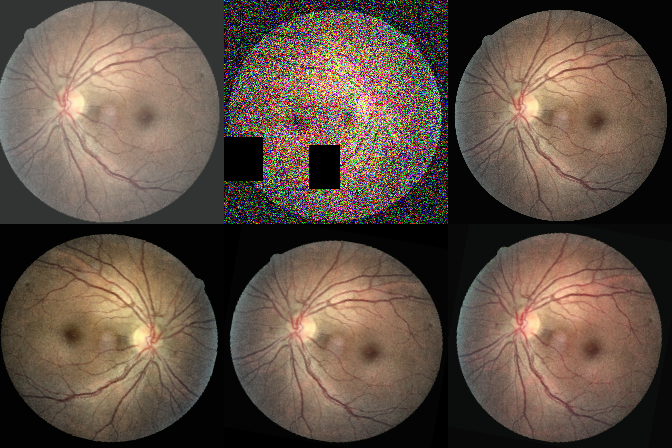

In [16]:
def plot_augmentations(img_path: str, n_samples: int = 6):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    transform = get_transforms("train")

    imgs_vis = []
    for i in range(n_samples):
        aug = transform(image=img)["image"]
        img_vis = aug.permute(1, 2, 0).numpy()
        img_vis = img_vis * np.array([0.229, 0.224, 0.225]) \
                          + np.array([0.485, 0.456, 0.406])
        img_vis = np.clip(img_vis * 255, 0, 255).astype(np.uint8)
        imgs_vis.append(PILImage.fromarray(img_vis))

    w, h = imgs_vis[0].size
    grid = PILImage.new("RGB", (w * 3, h * 2))
    for i, im in enumerate(imgs_vis):
        grid.paste(im, ((i % 3) * w, (i // 3) * h))

    display(grid)

img_path = str(next(Path(cfg.TRAIN_DIR / "0-noDR").glob("*.jpeg")))
plot_augmentations(img_path)

Definimos el dataset a utilizar:

In [17]:
FOLDER_TO_LABEL = {
    "0-noDR"           : 0,
    "1-mild"           : 1,
    "2-moderate"       : 2,
    "3-severe"         : 3,
    "4-proliferativeDR": 4,
}
 
class RetinopathyDataset(Dataset):
    """
    Acepta una lista de (img_path, label) ya construida externamente.
    Así podemos reutilizar la misma clase para train, val y test.
 
    Si TASK="binary", colapsa automáticamente las etiquetas:
        grado 0           → clase 0 (Sin RD)
        grados 1, 2, 3, 4 → clase 1 (Con RD)
    """
    def __init__(self, samples: list, split: str):
        self.transform = get_transforms(split)
        self.samples   = samples
        self.labels    = [s[1] for s in samples]
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = self.transform(image=img)
        return augmented["image"], torch.tensor(label, dtype=torch.long)
 
    def get_sample_weights(self):
        counts  = Counter(self.labels)
        weights = [1.0 / counts[l] for l in self.labels]
        return torch.FloatTensor(weights)
 
    def class_distribution(self):
        counts = Counter(self.labels)
        total  = len(self.samples)
        print(f"Distribución ({total} imágenes):")
        for cls, name in LABEL_NAMES.items():
            n   = counts.get(cls, 0)
            bar = "█" * (n // 20)
            print(f"  Clase {cls} ({name:16s}): {n:5d}  {bar}")

In [18]:
def scan_folder(root: Path) -> list:
    """
    Recorre una carpeta con estructura root/0-noDR/*.jpeg
    y devuelve una lista de (img_path, label).
    """
    samples = []
    for folder in sorted(root.iterdir()):
        if not folder.is_dir():
            continue
        if folder.name not in FOLDER_TO_LABEL:
            print(f"Carpeta ignorada: {folder.name}")
            continue
 
        original_label = FOLDER_TO_LABEL[folder.name]
        label = 1 if (cfg.TASK == "binary" and original_label > 0) \
                else original_label
 
        for img_path in folder.glob("*.*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                samples.append((str(img_path), label))
 
    return samples

Construimos los dataloaders:

In [19]:
def build_dataloaders(smoke_test: bool = cfg.SMOKE_TEST):
    # ── Escanear carpetas ─────────────────────────────
    all_train_samples = scan_folder(cfg.TRAIN_DIR)
    test_samples      = scan_folder(cfg.TEST_DIR)
 
    # ── Split train → train + val (estratificado) ─────
    train_samples, val_samples = train_test_split(
        all_train_samples,
        test_size    = cfg.VAL_SPLIT,
        random_state = cfg.SEED,
        stratify     = [s[1] for s in all_train_samples],
    )
 
    print(f"Split generado:")
    print(f"  train completo : {len(all_train_samples)}")
    print(f"  → train        : {len(train_samples)}")
    print(f"  → val          : {len(val_samples)}")
    print(f"  test           : {len(test_samples)}")
 
    # ── Smoke test: reducir tamaño ────────────────────
    if smoke_test:
        print(f"\nSMOKE TEST — usando subconjunto reducido")
        train_samples = random.sample(train_samples,
                                      min(cfg.SMOKE_TRAIN_SIZE, len(train_samples)))
        val_samples   = random.sample(val_samples,
                                      min(cfg.SMOKE_VAL_SIZE, len(val_samples)))
 
    # ── Construir datasets ────────────────────────────
    train_ds = RetinopathyDataset(train_samples, split="train")
    val_ds   = RetinopathyDataset(val_samples,   split="val")
    test_ds  = RetinopathyDataset(test_samples,  split="test")
 
    print(f"\nDistribución train:")
    train_ds.class_distribution()
 
    # ── Sampler ───────────────────────────────────────
    sampler = None
    if cfg.USE_WEIGHTED_SAMPLER and not smoke_test:
        weights = train_ds.get_sample_weights()
        sampler = WeightedRandomSampler(weights, len(weights))
 
    # ── DataLoaders ───────────────────────────────────
    loaders = {
        "train": DataLoader(train_ds,
                            batch_size  = cfg.BATCH_SIZE,
                            sampler     = sampler,
                            shuffle     = (sampler is None),
                            num_workers = cfg.NUM_WORKERS,
                            pin_memory  = True),
        "val":   DataLoader(val_ds,
                            batch_size  = cfg.BATCH_SIZE,
                            shuffle     = False,
                            num_workers = cfg.NUM_WORKERS,
                            pin_memory  = True),
        "test":  DataLoader(test_ds,
                            batch_size  = cfg.BATCH_SIZE,
                            shuffle     = False,
                            num_workers = cfg.NUM_WORKERS,
                            pin_memory  = True),
    }
 
    epochs = cfg.SMOKE_EPOCHS if smoke_test else cfg.EPOCHS
    return loaders, {"train": train_ds, "val": val_ds, "test": test_ds}, epochs
 
loaders, datasets, EPOCHS = build_dataloaders(cfg.SMOKE_TEST)

Split generado:
  train completo : 4864
  → train        : 3891
  → val          : 973
  test           : 1216

SMOKE TEST — usando subconjunto reducido

Distribución train:
Distribución (80 imágenes):
  Clase 0 (Sin RD          ):    53  ██
  Clase 1 (Con RD          ):    27  █


Verificación del batch:

In [21]:
imgs, labels = next(iter(loaders["train"]))
print(f"Shape del batch : {imgs.shape}")    # [B, 3, 512, 512]
print(f"Labels          : {labels}")
print(f"Dtype imagen    : {imgs.dtype}")
print(f"Min/Max valores : {imgs.min():.2f} / {imgs.max():.2f}")

Shape del batch : torch.Size([4, 3, 224, 224])
Labels          : tensor([0, 1, 1, 1])
Dtype imagen    : torch.float32
Min/Max valores : -2.12 / 2.64


### 3. Modelos

Podemos entrenar con diferentes arquitecturas:

In [22]:
MODELS = {
    "resnet50":        (models.resnet50,       2048),
    "resnet101":       (models.resnet101,      2048),
    "efficientnet_b3": (models.efficientnet_b3, 1536),
    "efficientnet_b4": (models.efficientnet_b4, 1792),
    "densenet121":     (models.densenet121,    1024),
}

print("Modelos disponibles:")
for name, (_, features) in MODELS.items():
    marker = " ← seleccionado" if name == cfg.MODEL_NAME else ""
    print(f"  {name:20s} ({features} features){marker}")

Modelos disponibles:
  resnet50             (2048 features)
  resnet101            (2048 features)
  efficientnet_b3      (1536 features) ← seleccionado
  efficientnet_b4      (1792 features)
  densenet121          (1024 features)


Construcción del modelo:

In [23]:
def build_model(model_name: str, num_classes: int,
                pretrained: bool = True,
                freeze_backbone: bool = False):
    """
    Carga una red preentrenada en ImageNet y reemplaza
    la cabeza de clasificación por una adaptada a nuestro problema.

    Cabeza binaria     (num_classes=2): 1 neurona + BCE internamente
    Cabeza multiclase  (num_classes=5): 5 neuronas + CrossEntropy

    freeze_backbone=True → solo entrena la cabeza (útil las primeras épocas
                           si el dataset es pequeño)
    """
    assert model_name in MODELS, \
        f"Modelo no soportado. Elige entre: {list(MODELS.keys())}"

    model_fn, in_features = MODELS[model_name]
    weights = "DEFAULT" if pretrained else None
    model   = model_fn(weights=weights)

    # ── Congelar backbone si se pide ─────────────────
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # ── Cabeza personalizada ──────────────────────────
    # Binaria  → 1 neurona  (sigmoid lo aplica BCEWithLogitsLoss)
    # Multiclase → N neuronas (softmax lo aplica CrossEntropyLoss)
    out_features = 1 if num_classes == 2 else num_classes

    head = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),        # normalización por lotes
        nn.ReLU(),
        nn.Dropout(0.4),            # regularización
        nn.Linear(512, out_features)
        # sin activación final → la aplica la loss internamente
    )

    # ── Asignar cabeza según arquitectura ─────────────
    if "resnet" in model_name:
        model.fc = head
        if freeze_backbone:
            for p in model.fc.parameters():
                p.requires_grad = True
        target_layers = [model.layer4[-1]]

    elif "efficientnet" in model_name:
        model.classifier = head
        if freeze_backbone:
            for p in model.classifier.parameters():
                p.requires_grad = True
        target_layers = [model.features[-1]]

    elif "densenet" in model_name:
        model.classifier = head
        if freeze_backbone:
            for p in model.classifier.parameters():
                p.requires_grad = True
        target_layers = [model.features.denseblock4]

    return model, target_layers

Instanciamos el modelo:

In [18]:
model, target_layers = build_model(
    cfg.MODEL_NAME,
    cfg.NUM_CLASSES,
    cfg.PRETRAINED,
    cfg.FREEZE_BACKBONE
)
model = model.to(cfg.DEVICE)

# Resumen de parámetros
total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen     = total - trainable

print(f"Modelo      : {cfg.MODEL_NAME}")
print(f"Preentrenado: {cfg.PRETRAINED}")
print(f"Clases      : {cfg.NUM_CLASSES}")
print(f"Device      : {cfg.DEVICE}")
print(f"\nParámetros:")
print(f"  Total      : {total:>12,}")
print(f"  Entrenables: {trainable:>12,}")
print(f"  Congelados : {frozen:>12,}")

Modelo      : efficientnet_b3
Preentrenado: True
Clases      : 5
Device      : cpu

Parámetros:
  Total      :   11,486,765
  Entrenables:   11,486,765
  Congelados :            0


Pasamos un batch de prueba para confirmar que el modelo funciona y que los shapes de entrada/salida son correctos:

In [19]:
with torch.no_grad():
    imgs, labels = next(iter(loaders["train"]))
    imgs = imgs.to(cfg.DEVICE)
    output = model(imgs)

print(f"Input shape  : {imgs.shape}")      # [B, 3, 512, 512]
print(f"Output shape : {output.shape}")    # [B, NUM_CLASSES]
print(f"Labels shape : {labels.shape}")    # [B]
print(f"\nEjemplo output (logits):\n{output[0].cpu()}")
print(f"\n Forward pass correcto")

Input shape  : torch.Size([4, 3, 224, 224])
Output shape : torch.Size([4, 5])
Labels shape : torch.Size([4])

Ejemplo output (logits):
tensor([-0.7824, -0.4347, -0.9022, -0.8494, -0.1286])

 Forward pass correcto


Visualización de la cabeza que hemos añadido (no todo el modelo):

In [20]:
if "resnet" in cfg.MODEL_NAME:
    print("Cabeza clasificadora:")
    print(model.fc)
elif "efficientnet" in cfg.MODEL_NAME:
    print("Cabeza clasificadora:")
    print(model.classifier)
elif "densenet" in cfg.MODEL_NAME:
    print("Cabeza clasificadora:")
    print(model.classifier)

print(f"\nCapa objetivo para CAM: {target_layers}")

Cabeza clasificadora:
Sequential(
  (0): Linear(in_features=1536, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=512, out_features=5, bias=True)
)

Capa objetivo para CAM: [Conv2dNormActivation(
  (0): Conv2d(384, 1536, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1536, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)]


Establecemos los pesos de clase para la loss dado que las clases están muy desbalanceadas en RD (el grado 0 domina). Para ello, asignamos más peso a las clases minoritarias:

In [21]:
if cfg.SMOKE_TEST:
    class_weights = torch.ones(cfg.NUM_CLASSES).to(cfg.DEVICE)
    print('Smoke test: pesos uniformes')
else:
    counts = Counter(datasets['train'].labels)
    total  = len(datasets['train'].labels)
    class_weights = torch.tensor([
        total / (cfg.NUM_CLASSES * counts[i])
        for i in range(cfg.NUM_CLASSES)
    ], dtype=torch.float32).to(cfg.DEVICE)
    print('Pesos por clase:')
    for i, (name, w) in enumerate(zip(LABEL_NAMES.values(), class_weights)):
        print(f'  Clase {i} ({name:16s}): {w:.4f}')

if cfg.TASK == 'binary':
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=class_weights[1].unsqueeze(0)
    )
    print('\nLoss: BCEWithLogitsLoss (binaria)')
else:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=cfg.LABEL_SMOOTHING
    )
    print('\nLoss: CrossEntropyLoss (multiclase)')

Smoke test: pesos uniformes

Loss: CrossEntropyLoss (multiclase)


### 4. Bucle de entrenamiento y early stopping

En primer lugar, definimos las condiciones de parada:

In [22]:
class EarlyStopping:
    """
    Para el entrenamiento si la val_loss no mejora en `patience` épocas.
    Guarda internamente el mejor modelo visto hasta ahora.
    """
    def __init__(self, patience: int = 7, min_delta: float = 1e-4,
                 checkpoint_path: str = 'checkpoints/best_model.pth'):
        self.patience         = patience
        self.min_delta        = min_delta
        self.checkpoint_path  = checkpoint_path
        self.counter          = 0
        self.best_loss        = float('inf')
        self.stop             = False

    def __call__(self, val_loss: float, model: nn.Module):
        if val_loss < self.best_loss - self.min_delta:
            # Mejora → guardar modelo y resetear contador
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.checkpoint_path)
            print(f'Mejor modelo guardado (val_loss={val_loss:.4f})')
        else:
            self.counter += 1
            print(f'Sin mejora {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
                print(f'Early stopping activado')

A continuación, definimos el optimizador y el scheduler:

In [23]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = cfg.LR,
    weight_decay = cfg.WEIGHT_DECAY
)

effective_warmup = min(cfg.WARMUP_EPOCHS, EPOCHS - 1)
effective_cosine = max(EPOCHS - effective_warmup, 1)

# Cosine Annealing con warmup lineal
# - Warmup: sube el lr gradualmente las primeras épocas
#   (evita destruir los pesos preentrenados al inicio)
# - Cosine: baja el lr suavemente hasta casi 0 al final
warmup = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor = 0.1,
    total_iters  = effective_warmup
)
cosine = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = effective_cosine,
    eta_min = 1e-7
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers = [warmup, cosine],
    milestones = [effective_warmup]
)

early_stopping = EarlyStopping(
    patience         = cfg.PATIENCE,
    checkpoint_path  = str(cfg.CHECKPOINT_DIR / 'best_model.pth')
)

print(f'Optimizador : AdamW (lr={cfg.LR}, wd={cfg.WEIGHT_DECAY})')
print(f'Scheduler   : Warmup {cfg.WARMUP_EPOCHS} épocas → CosineAnnealing')
print(f'Early stop  : patience={cfg.PATIENCE}')

Optimizador : AdamW (lr=0.0001, wd=0.0001)
Scheduler   : Warmup 3 épocas → CosineAnnealing
Early stop  : patience=7


Definición de la función de entrenamiento:

In [24]:
scaler = torch.cuda.amp.GradScaler(enabled=cfg.MIXED_PRECISION)

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs   = imgs.to(cfg.DEVICE)
        labels = labels.to(cfg.DEVICE)

        # Binaria: labels float [B] | Multiclase: labels long [B]
        if cfg.TASK == 'binary':
            labels_loss = labels.float().unsqueeze(1)
        else:
            labels_loss = labels

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=cfg.MIXED_PRECISION):
            output = model(imgs)
            loss   = criterion(output, labels_loss)

        scaler.scale(loss).backward()
        # Clip gradientes para evitar explosión
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)

        # Predicciones
        if cfg.TASK == 'binary':
            preds = (torch.sigmoid(output) > 0.5).long().squeeze(1)
        else:
            preds = output.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

    return total_loss / total, correct / total

Definición de la función de evaluación:

In [25]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs   = imgs.to(cfg.DEVICE)
        labels = labels.to(cfg.DEVICE)

        if cfg.TASK == 'binary':
            labels_loss = labels.float().unsqueeze(1)
        else:
            labels_loss = labels

        output = model(imgs)
        loss   = criterion(output, labels_loss)
        total_loss += loss.item() * imgs.size(0)

        # Probabilidades y predicciones
        if cfg.TASK == 'binary':
            probs = torch.sigmoid(output).squeeze(1)   # [B]
            preds = (probs > 0.5).long()
            probs_np = probs.cpu().numpy()
        else:
            probs = torch.softmax(output, dim=1)        # [B, C]
            preds = probs.argmax(dim=1)
            probs_np = probs.cpu().numpy()

        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs_np)

    return (total_loss / total,
            correct / total,
            np.array(all_preds),
            np.array(all_labels),
            np.array(all_probs))

Definición del bucle de entrenamiento:

In [ ]:
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [], 'lr': []}

print('Iniciando entrenamiento...\n')
print(f'   Épocas    : {EPOCHS}')
print(f'   Modo      : {"SMOKE TEST" if cfg.SMOKE_TEST else "COMPLETO"}')
print(f'   Tarea     : {cfg.TASK}\n')

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Época {epoch:02d}/{EPOCHS}  lr={current_lr:.2e}')

    train_loss, train_acc = train_one_epoch(
        model, loaders['train'], optimizer, criterion, scaler)

    val_loss, val_acc, _, _, _ = evaluate(
        model, loaders['val'], criterion)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f'  Loss → train: {train_loss:.4f} | val: {val_loss:.4f}')
    print(f'  Acc  → train: {train_acc:.4f} | val: {val_acc:.4f}')

    early_stopping(val_loss, model)
    if early_stopping.stop:
        print(f'\n⏹  Entrenamiento parado en época {epoch}')
        break
    print()

Iniciando entrenamiento...

   Épocas    : 3
   Modo      : SMOKE TEST
   Tarea     : multiclass

Época 01/3  lr=1.00e-05


  Loss → train: 1.6410 | val: 1.6060
  Acc  → train: 0.2625 | val: 0.2000
Mejor modelo guardado (val_loss=1.6060)

Época 02/3  lr=5.50e-05


  Loss → train: 1.6755 | val: 1.5210
  Acc  → train: 0.2125 | val: 0.3500
Mejor modelo guardado (val_loss=1.5210)

Época 03/3  lr=1.00e-04


  Loss → train: 1.5036 | val: 1.4307
  Acc  → train: 0.3625 | val: 0.4000
Mejor modelo guardado (val_loss=1.4307)



Graficamos las curvas de entrenamiento:

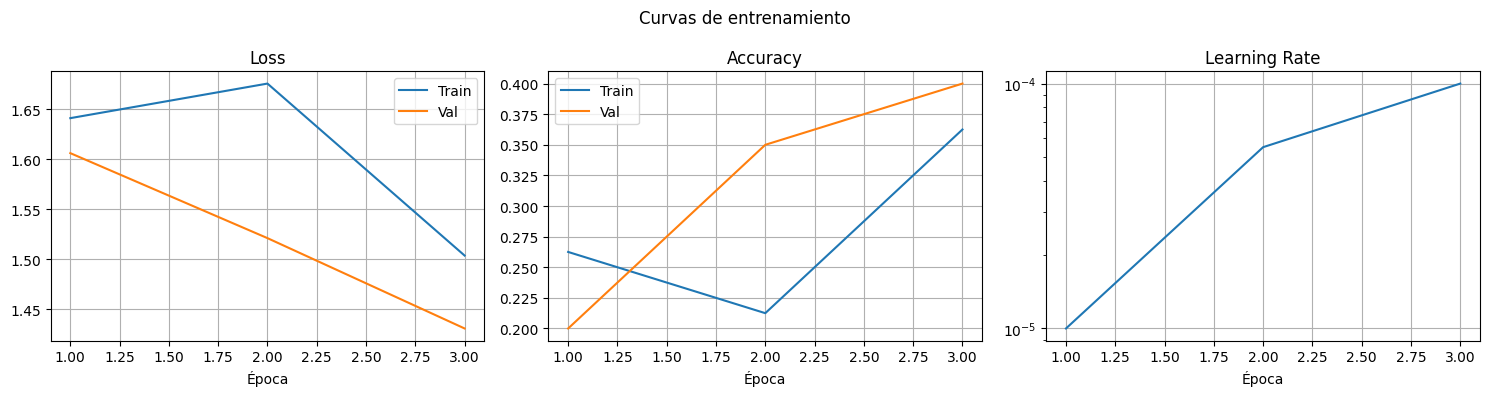

In [27]:
def plot_history(history: dict):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(epochs, history['lr'])
    axes[2].set_title('Learning Rate')
    axes[2].set_xlabel('Época')
    axes[2].set_yscale('log')
    axes[2].grid(True)

    plt.suptitle('Curvas de entrenamiento')
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / 'training_history.png', dpi=150)
    plt.show()

plot_history(history)

Cargamos el mejor modelo para evaluación:

In [28]:
checkpoint_path = cfg.CHECKPOINT_DIR / 'best_model.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=cfg.DEVICE))
model.eval()
print(f'Mejor modelo cargado desde {checkpoint_path}')

Mejor modelo cargado desde checkpoints/best_model.pth


## 5. Evaluación y métricas

En primer lugar, evaluamos en test:

In [29]:
test_loss, test_acc, preds, labels, probs = evaluate(
    model, loaders['test'], criterion)

print('=' * 50)
print('RESULTADOS EN TEST')
print('=' * 50)
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_acc:.4f}')

RESULTADOS EN TEST
  Loss     : 1.4993
  Accuracy : 0.3684


Calculamos las métricas específicas en función de la tarea (clasificación binaria o clasificación multiclase):

In [30]:
if cfg.TASK == 'binary':
    # AUC-ROC
    auc = roc_auc_score(labels, probs)
    print(f'  AUC-ROC  : {auc:.4f}')

    # Reporte por clase
    print('\nReporte por clase:')
    print(classification_report(labels, preds,
                                 target_names=list(BINARY_LABELS.values()),
                                 digits=4))
else:
    # Kappa cuadrático — métrica estándar en RD
    # Penaliza más los errores grandes (confundir grado 0 con 4)
    # que los pequeños (confundir grado 1 con 2)
    kappa = cohen_kappa_score(labels, preds, weights='quadratic')
    print(f'  Kappa cuadrático : {kappa:.4f}')

    # AUC macro one-vs-rest
    try:
        auc = roc_auc_score(labels, probs,
                            multi_class='ovr', average='macro')
        print(f'  AUC macro (OvR)  : {auc:.4f}')
    except Exception as e:
        print(f'  AUC no calculable: {e}')

    # Reporte por clase
    print('\nReporte por clase:')
    print(classification_report(labels, preds,
                                 target_names=list(GRADES.values()),
                                 digits=4))

  Kappa cuadrático : 0.0595
  AUC macro (OvR)  : 0.5336

Reporte por clase:
               precision    recall  f1-score   support

       Sin RD     0.3973    0.7623    0.5224       467
         Leve     0.2222    0.0282    0.0500       213
     Moderada     0.3091    0.2401    0.2703       354
       Severa     0.0556    0.0105    0.0177        95
Proliferativa     0.0000    0.0000    0.0000        87

     accuracy                         0.3684      1216
    macro avg     0.1968    0.2082    0.1721      1216
 weighted avg     0.2858    0.3684    0.2894      1216



Calculamos la matriz de confusión:

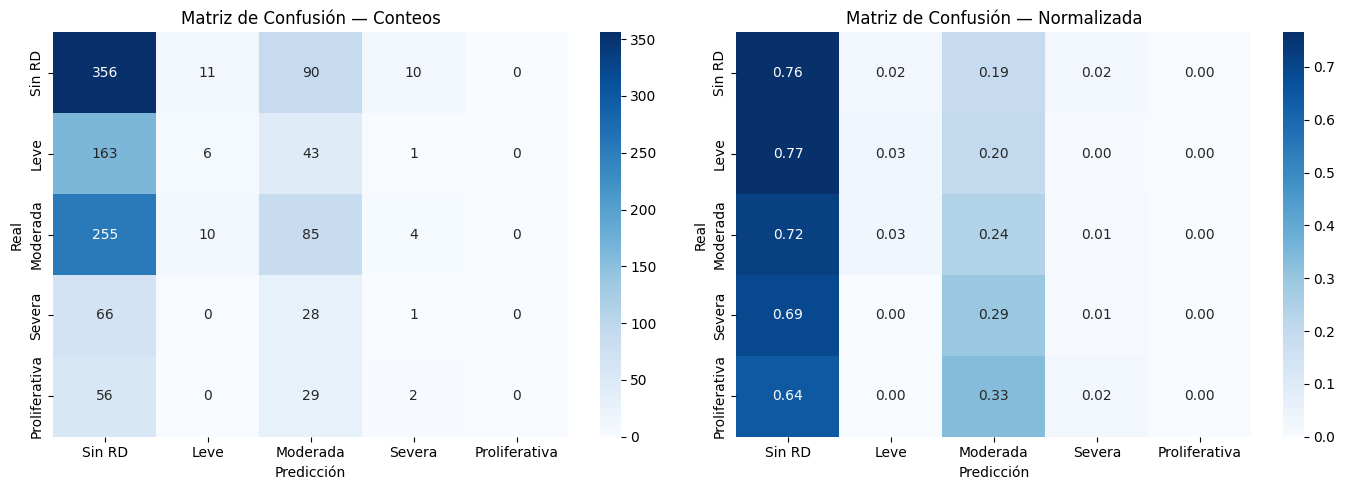

In [31]:
def plot_confusion_matrix(labels, preds):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    label_names = list(BINARY_LABELS.values()) if cfg.TASK == 'binary' \
                  else list(GRADES.values())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, fmt, title in zip(
            axes,
            [cm, cm_norm],
            ['d', '.2f'],
            ['Conteos', 'Normalizada']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=label_names,
                    yticklabels=label_names,
                    ax=ax)
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.set_title(f'Matriz de Confusión — {title}')

    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
    plt.show()

plot_confusion_matrix(labels, preds)

Mostramos la *Curva ROC* (clasificación binaria) o *AUC por clase* (clasificación multiclase):

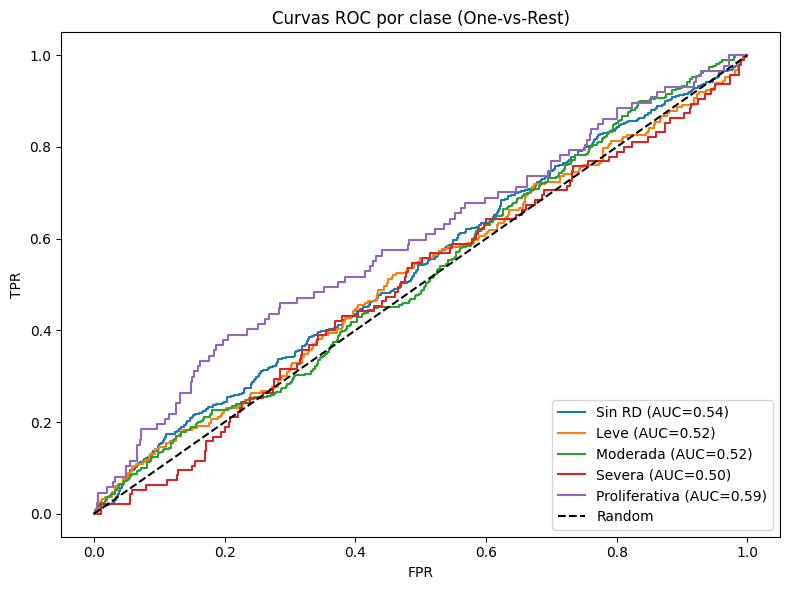

In [32]:
if cfg.TASK == 'binary':
    fig, ax = plt.subplots(figsize=(6, 6))
    RocCurveDisplay.from_predictions(labels, probs, ax=ax,
                                     name='EfficientNet-B3')
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_title('Curva ROC — Clasificación Binaria')
    ax.legend()
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / 'roc_curve.png', dpi=150)
    plt.show()

else:
    # Una curva ROC por clase (one-vs-rest)
    from sklearn.metrics import roc_curve, auc

    labels_bin = label_binarize(labels, classes=list(range(cfg.NUM_CLASSES)))

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, name in GRADES.items():
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        auc_score   = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('Curvas ROC por clase (One-vs-Rest)')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / 'roc_curves.png', dpi=150)
    plt.show()

Por último, se mostrarán ejemplos de predicciones correctas e incorrectas:

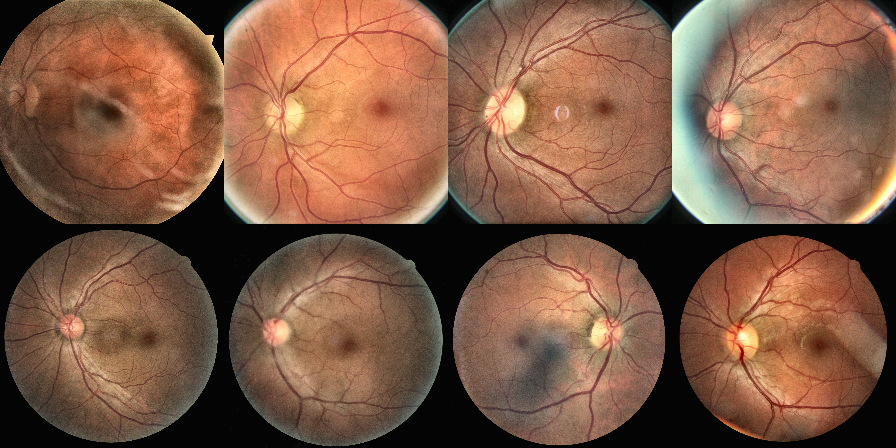

Fila 1 — Correctas:
  Real: Sin RD       | Pred: Sin RD       | Prob: 0.33
  Real: Sin RD       | Pred: Sin RD       | Prob: 0.42
  Real: Sin RD       | Pred: Sin RD       | Prob: 0.42
  Real: Sin RD       | Pred: Sin RD       | Prob: 0.55

Fila 2 — Incorrectas:
  Real: Sin RD       | Pred: Moderada     | Prob: 0.35
  Real: Sin RD       | Pred: Moderada     | Prob: 0.34
  Real: Sin RD       | Pred: Moderada     | Prob: 0.36
  Real: Sin RD       | Pred: Moderada     | Prob: 0.26


In [33]:
def plot_predictions(n_correct: int = 4, n_wrong: int = 4):
    from PIL import Image as PILImage
    from IPython.display import display

    test_ds = datasets['test']
    model.eval()

    correct_samples, wrong_samples = [], []

    with torch.no_grad():
        for idx in range(len(test_ds)):
            if len(correct_samples) >= n_correct and \
               len(wrong_samples)   >= n_wrong:
                break

            img_tensor, label = test_ds[idx]
            output = model(img_tensor.unsqueeze(0).to(cfg.DEVICE))

            if cfg.TASK == 'binary':
                prob = torch.sigmoid(output).item()
                pred = int(prob > 0.5)
            else:
                probs_t = torch.softmax(output, dim=1)[0]
                pred    = probs_t.argmax().item()
                prob    = probs_t[pred].item()

            # Desnormalizar para visualizar
            img_vis = img_tensor.permute(1, 2, 0).numpy()
            img_vis = img_vis * np.array([0.229, 0.224, 0.225]) \
                              + np.array([0.485, 0.456, 0.406])
            img_vis = np.clip(img_vis * 255, 0, 255).astype(np.uint8)
            pil_img = PILImage.fromarray(img_vis)

            entry = (pil_img, label.item(), pred, prob)
            if pred == label.item() and len(correct_samples) < n_correct:
                correct_samples.append(entry)
            elif pred != label.item() and len(wrong_samples) < n_wrong:
                wrong_samples.append(entry)

    # Construir grid: fila 1 = correctas, fila 2 = incorrectas
    all_samples = correct_samples + wrong_samples
    w, h = all_samples[0][0].size
    cols = max(n_correct, n_wrong)
    grid = PILImage.new('RGB', (w * cols, h * 2), color=(255, 255, 255))

    for i, (img, true, pred, prob) in enumerate(all_samples):
        row = 0 if i < n_correct else 1
        col = i if i < n_correct else i - n_correct
        grid.paste(img, (col * w, row * h))

    display(grid)

    # Imprimir etiquetas debajo
    print('Fila 1 — Correctas:')
    for img, true, pred, prob in correct_samples:
        print(f'  Real: {LABEL_NAMES[true]:12s} | '
              f'Pred: {LABEL_NAMES[pred]:12s} | '
              f'Prob: {prob:.2f}')
    print('\nFila 2 — Incorrectas:')
    for img, true, pred, prob in wrong_samples:
        print(f'  Real: {LABEL_NAMES[true]:12s} | '
              f'Pred: {LABEL_NAMES[pred]:12s} | '
              f'Prob: {prob:.2f}')

plot_predictions()

### 6. Clasificación binaria y multiclase

A continuación, entrenamos y evaluamos ambas tareas con todos los datos:


  TAREA: MULTICLASS
Split generado:
  train completo : 4864
  → train        : 3891
  → val          : 973
  test           : 1216

Distribución train:
Distribución (3891 imágenes):
  Clase 0 (Sin RD          ):  2105  █████████████████████████████████████████████████████████████████████████████████████████████████████████
  Clase 1 (Leve            ):   498  ████████████████████████
  Clase 2 (Moderada        ):  1026  ███████████████████████████████████████████████████
  Clase 3 (Severa          ):   142  ███████
  Clase 4 (Proliferativa   ):   120  ██████
Época 01/30  lr=1.00e-05


  Loss → train: 1.5319 | val: 3.3312
  Acc  → train: 0.2159 | val: 0.0483
Mejor modelo guardado (val_loss=3.3312)

Época 02/30  lr=4.00e-05


  Loss → train: 1.3787 | val: 2.9955
  Acc  → train: 0.2842 | val: 0.1244
Mejor modelo guardado (val_loss=2.9955)

Época 03/30  lr=7.00e-05


  Loss → train: 1.2995 | val: 2.3995
  Acc  → train: 0.3359 | val: 0.1182
Mejor modelo guardado (val_loss=2.3995)

Época 04/30  lr=1.00e-04


  Loss → train: 1.2781 | val: 2.2441
  Acc  → train: 0.3524 | val: 0.1244
Mejor modelo guardado (val_loss=2.2441)

Época 05/30  lr=9.97e-05


...

  Loss → train: 0.9668 | val: 2.3186
  Acc  → train: 0.4863 | val: 0.1624
Sin mejora 4/7

Época 14/30  lr=6.98e-05


  Loss → train: 0.9478 | val: 2.2343
  Acc  → train: 0.4922 | val: 0.1881
Sin mejora 5/7

Época 15/30  lr=6.44e-05


  Loss → train: 0.9712 | val: 2.2641
  Acc  → train: 0.4857 | val: 0.1881
Sin mejora 6/7

Época 16/30  lr=5.87e-05


  Loss → train: 0.9333 | val: 2.3126
  Acc  → train: 0.5073 | val: 0.1757
Sin mejora 7/7
Early stopping activado

⏹  Early stopping en época 16



TEST — MULTICLASS
  Loss     : 2.4141
  Accuracy : 0.2303
  Kappa cuadrático : 0.3083
  AUC macro (OvR)  : 0.6893
               precision    recall  f1-score   support

       Sin RD     0.5660    0.0642    0.1154       467
         Leve     0.2207    0.5305    0.3117       213
     Moderada     0.3958    0.0537    0.0945       354
       Severa     0.2072    0.5474    0.3006        95
Proliferativa     0.1875    0.7586    0.3007        87

     accuracy                         0.2303      1216
    macro avg     0.3154    0.3909    0.2246      1216
 weighted avg     0.4009    0.2303    0.1714      1216



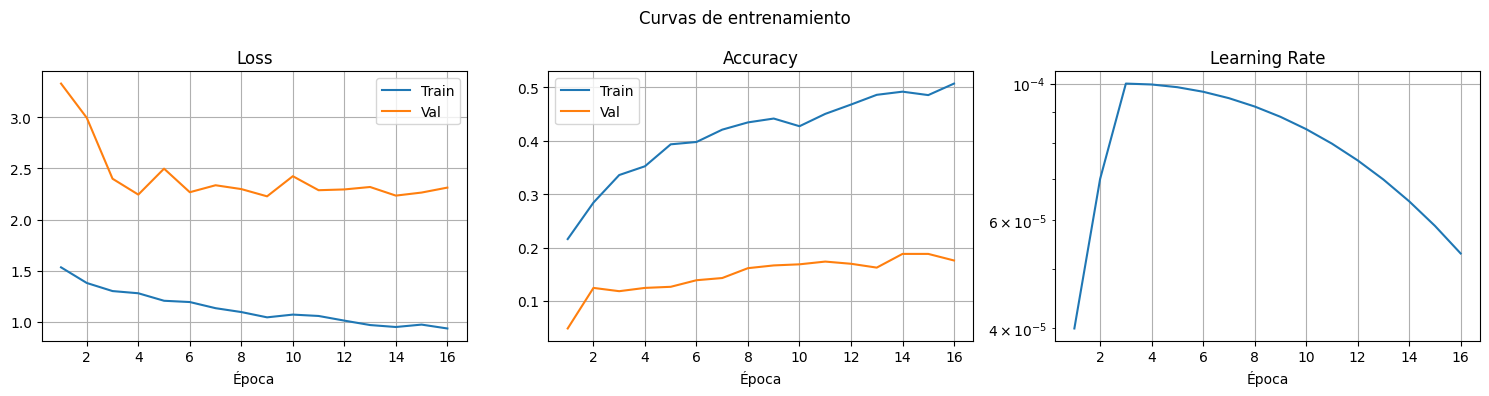

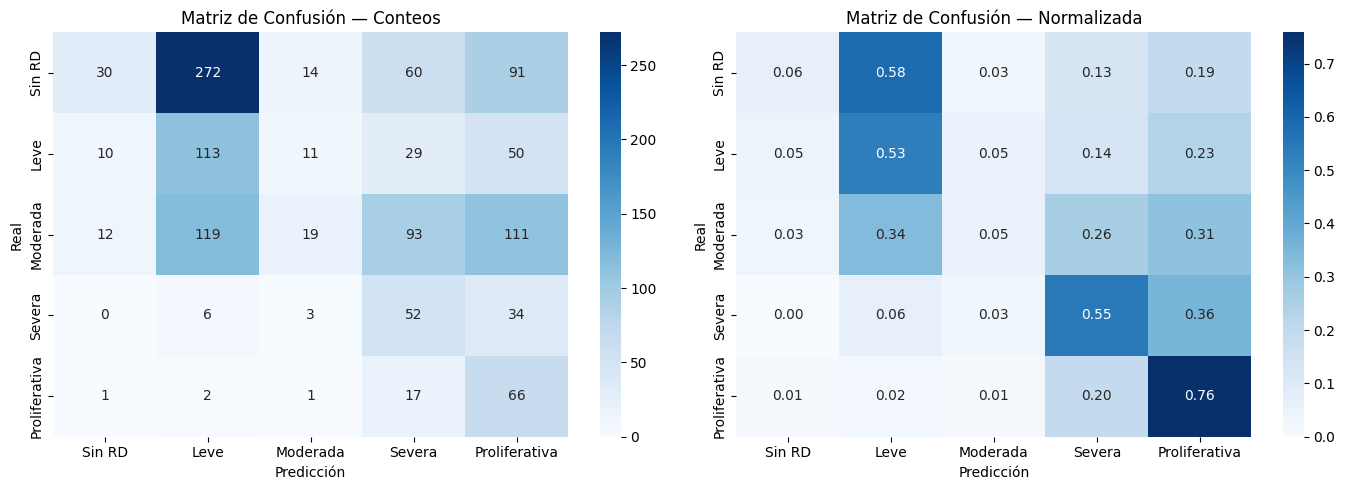

In [37]:
# 'binary', 
for task in ['multiclass']:

    # ── Config ───────────────────────────────────────
    cfg.TASK        = task
    cfg.NUM_CLASSES = 2 if task == 'binary' else 5
    cfg.SMOKE_TEST  = False
    LABEL_NAMES     = BINARY_LABELS if task == 'binary' else GRADES

    print('\n' + '=' * 50)
    print(f'  TAREA: {task.upper()}')
    print('=' * 50)

    # ── Datos ────────────────────────────────────────
    loaders, datasets, EPOCHS = build_dataloaders(smoke_test=False)

    # ── Modelo ───────────────────────────────────────
    model, target_layers = build_model(
        cfg.MODEL_NAME, cfg.NUM_CLASSES,
        cfg.PRETRAINED, cfg.FREEZE_BACKBONE)
    model = model.to(cfg.DEVICE)

    # ── Loss ─────────────────────────────────────────
    counts = Counter(datasets['train'].labels)
    total  = len(datasets['train'].labels)
    class_weights = torch.tensor([
        total / (cfg.NUM_CLASSES * counts[i])
        for i in range(cfg.NUM_CLASSES)
    ], dtype=torch.float32).to(cfg.DEVICE)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=class_weights[1].unsqueeze(0)) \
        if task == 'binary' else \
        nn.CrossEntropyLoss(weight=class_weights,
                            label_smoothing=cfg.LABEL_SMOOTHING)

    # ── Optimizador y scheduler ───────────────────────
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)

    effective_warmup = min(cfg.WARMUP_EPOCHS, EPOCHS - 1)
    effective_cosine = max(EPOCHS - effective_warmup, 1)
    scheduler = optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            optim.lr_scheduler.LinearLR(
                optimizer, start_factor=0.1,
                total_iters=effective_warmup),
            optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=effective_cosine, eta_min=1e-7)
        ],
        milestones=[effective_warmup])

    scaler     = torch.cuda.amp.GradScaler(enabled=cfg.MIXED_PRECISION)
    early_stop = EarlyStopping(
        patience        = cfg.PATIENCE,
        checkpoint_path = str(cfg.CHECKPOINT_DIR / f'best_model_{task}.pth'))

    # ── Entrenamiento ─────────────────────────────────
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  [],
               'lr':         []}

    for epoch in range(1, EPOCHS + 1):
        lr = optimizer.param_groups[0]['lr']
        print(f'Época {epoch:02d}/{EPOCHS}  lr={lr:.2e}')

        train_loss, train_acc = train_one_epoch(
            model, loaders['train'], optimizer, criterion, scaler)
        val_loss, val_acc, _, _, _ = evaluate(
            model, loaders['val'], criterion)

        scheduler.step()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f'  Loss → train: {train_loss:.4f} | val: {val_loss:.4f}')
        print(f'  Acc  → train: {train_acc:.4f} | val: {val_acc:.4f}')

        early_stop(val_loss, model)
        if early_stop.stop:
            print(f'\n⏹  Early stopping en época {epoch}')
            break
        print()

    # ── Cargar mejor modelo ───────────────────────────
    model.load_state_dict(torch.load(
        cfg.CHECKPOINT_DIR / f'best_model_{task}.pth',
        map_location=cfg.DEVICE))
    model.eval()

    # ── Métricas y visualizaciones ────────────────────
    test_loss, test_acc, preds, labels, probs = evaluate(
        model, loaders['test'], criterion)

    print(f'\nTEST — {task.upper()}')
    print(f'  Loss     : {test_loss:.4f}')
    print(f'  Accuracy : {test_acc:.4f}')

    if task == 'binary':
        print(f'  AUC-ROC  : {roc_auc_score(labels, probs):.4f}')
    else:
        kappa = cohen_kappa_score(labels, preds, weights='quadratic')
        print(f'  Kappa cuadrático : {kappa:.4f}')
        try:
            auc_score = roc_auc_score(labels, probs,
                                       multi_class='ovr', average='macro')
            print(f'  AUC macro (OvR)  : {auc_score:.4f}')
        except Exception as e:
            print(f'  AUC no calculable: {e}')

    print(classification_report(labels, preds,
                                  target_names=list(LABEL_NAMES.values()),
                                  digits=4))
    plot_history(history)
    plot_confusion_matrix(labels, preds)

Split generado:
  train completo : 4864
  → train        : 3891
  → val          : 973
  test           : 1216

Distribución train:
Distribución (3891 imágenes):
  Clase 0 (Sin RD          ):  2105  █████████████████████████████████████████████████████████████████████████████████████████████████████████
  Clase 1 (Con RD          ):  1786  █████████████████████████████████████████████████████████████████████████████████████████


AUC-ROC : 0.7543
              precision    recall  f1-score   support

      Sin RD     0.5451    0.8672    0.6694       467
      Con RD     0.8689    0.5487    0.6727       749

    accuracy                         0.6711      1216
   macro avg     0.7070    0.7080    0.6710      1216
weighted avg     0.7446    0.6711    0.6714      1216



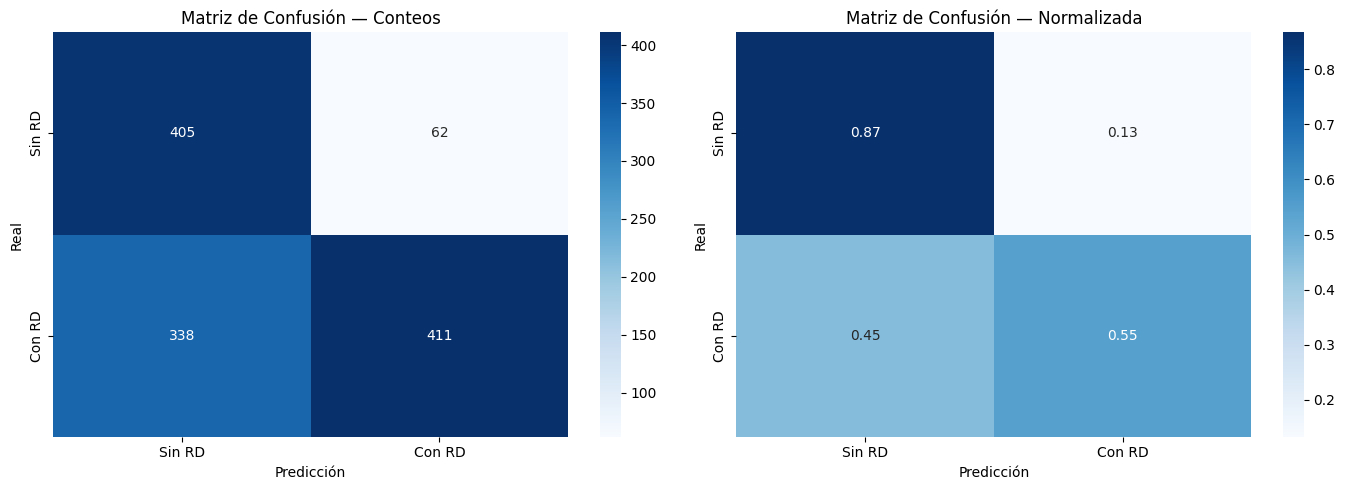

In [35]:
# Cargar modelo binario ya entrenado
cfg.TASK        = 'binary'
cfg.NUM_CLASSES = 2
LABEL_NAMES     = BINARY_LABELS

loaders, datasets, EPOCHS = build_dataloaders(smoke_test=False)

model, target_layers = build_model(
    cfg.MODEL_NAME, cfg.NUM_CLASSES,
    cfg.PRETRAINED, cfg.FREEZE_BACKBONE)
model.load_state_dict(torch.load(
    cfg.CHECKPOINT_DIR / 'best_model_binary.pth',
    map_location=cfg.DEVICE))
model = model.to(cfg.DEVICE)
model.eval()

# ── Redefinir criterion para binario ──────────────
counts = Counter(datasets['train'].labels)
total  = len(datasets['train'].labels)
class_weights = torch.tensor([
    total / (cfg.NUM_CLASSES * counts[i])
    for i in range(cfg.NUM_CLASSES)
], dtype=torch.float32).to(cfg.DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights[1].unsqueeze(0))

# ── Evaluar ───────────────────────────────────────
test_loss, test_acc, preds, labels, probs = evaluate(
    model, loaders['test'], criterion)

print(f'AUC-ROC : {roc_auc_score(labels, probs):.4f}')
print(classification_report(labels, preds,
                              target_names=list(LABEL_NAMES.values()),
                              digits=4))
plot_confusion_matrix(labels, preds)

In [26]:
# Calcular accuracy de los modelos guardados

for task in ['binary', 'multiclass']:
    print(f'\n── {task.upper()} ──')

    # Config
    cfg.TASK        = task
    cfg.NUM_CLASSES = 2 if task == 'binary' else 5
    LABEL_NAMES     = BINARY_LABELS if task == 'binary' else GRADES

    # Datos
    loaders, datasets, _ = build_dataloaders(smoke_test=False)

    # Modelo
    model, _ = build_model(cfg.MODEL_NAME, cfg.NUM_CLASSES,
                            cfg.PRETRAINED, cfg.FREEZE_BACKBONE)
    model.load_state_dict(torch.load(
        cfg.CHECKPOINT_DIR / f'best_model_{task}.pth',
        map_location=cfg.DEVICE))
    model = model.to(cfg.DEVICE)
    model.eval()

    # Loss (necesaria para evaluate)
    counts = Counter(datasets['test'].labels)
    total  = len(datasets['test'].labels)
    class_weights = torch.tensor([
        total / (cfg.NUM_CLASSES * counts.get(i, 1))
        for i in range(cfg.NUM_CLASSES)
    ], dtype=torch.float32).to(cfg.DEVICE)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=class_weights[1].unsqueeze(0)) \
        if task == 'binary' else \
        nn.CrossEntropyLoss(weight=class_weights)

    # Evaluar
    test_loss, test_acc, preds, labels, probs = evaluate(
        model, loaders['test'], criterion)

    print(f'  Accuracy : {test_acc:.4f}')
    print(f'  Loss     : {test_loss:.4f}')
    if task == 'binary':
        print(f'  AUC-ROC  : {roc_auc_score(labels, probs):.4f}')
    else:
        kappa = cohen_kappa_score(labels, preds, weights='quadratic')
        print(f'  Kappa    : {kappa:.4f}')
    print(classification_report(labels, preds,
                                  target_names=list(LABEL_NAMES.values()),
                                  digits=4))


── BINARY ──
Split generado:
  train completo : 4864
  → train        : 3891
  → val          : 973
  test           : 1216

Distribución train:
Distribución (3891 imágenes):
  Clase 0 (Sin RD          ):  2105  █████████████████████████████████████████████████████████████████████████████████████████████████████████
  Clase 1 (Con RD          ):  1786  █████████████████████████████████████████████████████████████████████████████████████████


  Accuracy : 0.6711
  Loss     : 0.5457
  AUC-ROC  : 0.7543
              precision    recall  f1-score   support

      Sin RD     0.5451    0.8672    0.6694       467
      Con RD     0.8689    0.5487    0.6727       749

    accuracy                         0.6711      1216
   macro avg     0.7070    0.7080    0.6710      1216
weighted avg     0.7446    0.6711    0.6714      1216


── MULTICLASS ──
Split generado:
  train completo : 4864
  → train        : 3891
  → val          : 973
  test           : 1216

Distribución train:
Distribución (3891 imágenes):
  Clase 0 (Sin RD          ):  2105  █████████████████████████████████████████████████████████████████████████████████████████████████████████
  Clase 1 (Leve            ):   498  ████████████████████████
  Clase 2 (Moderada        ):  1026  ███████████████████████████████████████████████████
  Clase 3 (Severa          ):   142  ███████
  Clase 4 (Proliferativa   ):   120  ██████


  Accuracy : 0.2303
  Loss     : 1.6924
  Kappa    : 0.3083
               precision    recall  f1-score   support

       Sin RD     0.5660    0.0642    0.1154       467
         Leve     0.2207    0.5305    0.3117       213
     Moderada     0.3958    0.0537    0.0945       354
       Severa     0.2072    0.5474    0.3006        95
Proliferativa     0.1875    0.7586    0.3007        87

     accuracy                         0.2303      1216
    macro avg     0.3154    0.3909    0.2246      1216
 weighted avg     0.4009    0.2303    0.1714      1216

